<a href="https://colab.research.google.com/github/narendrapatel6321-dotcom/bank_churn_prediction/blob/main/notebooks/churn_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 - Setup

In [1]:
import os
import urllib.request
base_path = "https://raw.githubusercontent.com/narendrapatel6321-dotcom/bank_churn_prediction/main/helpers"
files = {
    "helpers/__init__.py"              : f"{base_path}/__init__.py",
    "helpers/feature_engineering.py"   : f"{base_path}/feature_engineering.py",
    "helpers/tuning.py"                : f"{base_path}/tuning.py",
    "helpers/threshold.py"             : f"{base_path}/threshold.py",
    "helpers/shap_utils.py"            : f"{base_path}/shap_utils.py",
    "helpers/eda_plots.py"             : f"{base_path}/eda_plots.py",
    "helpers/eval_plots.py"            : f"{base_path}/eval_plots.py",
    "helpers/persistence.py"           : f"{base_path}/persistence.py",
}

os.makedirs("helpers", exist_ok=True)
for filename, url in files.items():
    urllib.request.urlretrieve(url, filename)
    print(f"Downloaded: {filename}")

Downloaded: helpers/__init__.py
Downloaded: helpers/feature_engineering.py
Downloaded: helpers/tuning.py
Downloaded: helpers/threshold.py
Downloaded: helpers/shap_utils.py
Downloaded: helpers/eda_plots.py
Downloaded: helpers/eval_plots.py
Downloaded: helpers/persistence.py


In [2]:
!pip install -q optuna lightgbm xgboost catboost shap imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


In [3]:
import warnings
import json
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn           as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics         import (
    roc_auc_score, f1_score, recall_score, precision_score,precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from helpers.feature_engineering import build_pipeline
from helpers.tuning               import run_optuna_study, make_objective
from helpers.threshold            import find_optimal_threshold
from helpers.shap_utils           import (
    build_shap_explainer, get_shap_values_class1,
    get_transformed_test_data,
    plot_shap_summary, plot_shap_waterfall,
)
from helpers.eda_plots  import (
    plot_class_imbalance, plot_kde_by_churn,
    plot_churn_rate_bar, plot_correlation_heatmap,
)
from helpers.eval_plots import (
    plot_threshold_curve, plot_confusion_matrix,
    plot_roc_curve, plot_pr_curve,
    plot_calibration_curve, plot_error_analysis,
)
from helpers.persistence import save_pipeline_and_results

import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

os.makedirs("models",          exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

In [4]:
GITHUB_RAW_URL = "https://raw.githubusercontent.com/narendrapatel6321-dotcom/bank_churn_prediction/main/data/Churn_Modelling.csv"
SEED = 21

# 2 - DATA LOADING & AUDIT

In [5]:
df_raw = pd.read_csv(GITHUB_RAW_URL)
df     = df_raw.copy()

print(f"Dataset Shape: {df.shape} | Duplicates: {df.duplicated().sum()}")

audit_table = pd.concat([
    df.dtypes.to_frame('Dtype'),
    df.isna().sum().to_frame('Nulls'),
    df.nunique().to_frame('Unique'),
    df.describe().T[['min', 'max']]
], axis=1).fillna('-')

display(audit_table)

Dataset Shape: (10000, 14) | Duplicates: 0


,Dtype,Nulls,Unique,min,max
RowNumber,int64,0,10000,1.0,10000.0
CustomerId,int64,0,10000,15565701.0,15815690.0
Surname,object,0,2932,-,-
CreditScore,int64,0,460,350.0,850.0
Geography,object,0,3,-,-
Gender,object,0,2,-,-
Age,int64,0,70,18.0,92.0
Tenure,int64,0,11,0.0,10.0
Balance,float64,0,6382,0.0,250898.09
NumOfProducts,int64,0,4,1.0,4.0


# 3 - TRAIN / TEST SPLIT

In [6]:
TARGET    = "Exited"
DROP_COLS = ["RowNumber", "CustomerId", "Surname"]
TEST_SIZE = 0.10

X = df.drop(columns=[TARGET] + DROP_COLS)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
)

train_df           = X_train.copy()
train_df['Exited'] = y_train.values

print(f"Train : {X_train.shape}  |  churn rate = {y_train.mean():.1%}")
print(f"Test  : {X_test.shape}   |  churn rate = {y_test.mean():.1%}")

Train : (9000, 10)  |  churn rate = 20.4%
Test  : (1000, 10)   |  churn rate = 20.4%


# 4 - EXPLORATORY DATA ANALYSIS

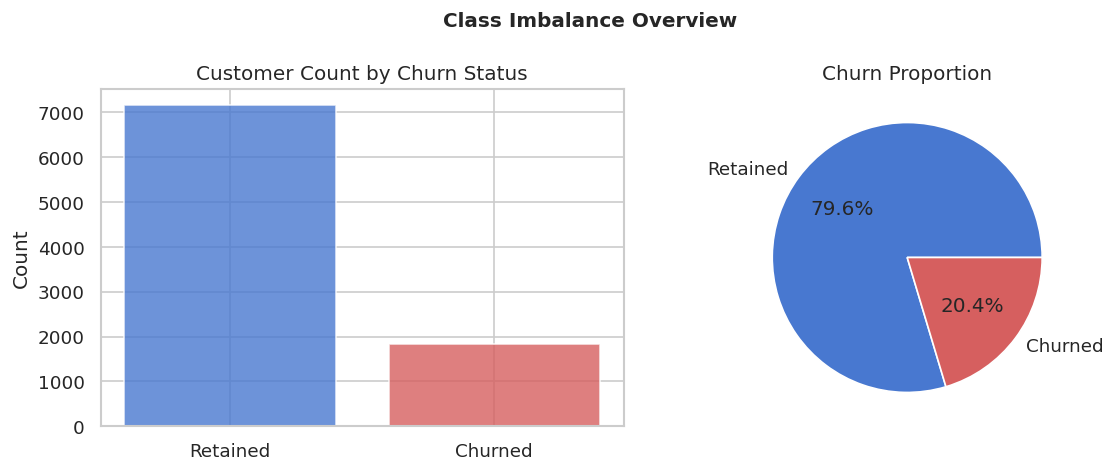

In [7]:
plot_class_imbalance(train_df,
    save_path="reports/figures/eda_01_class_imbalance.png")

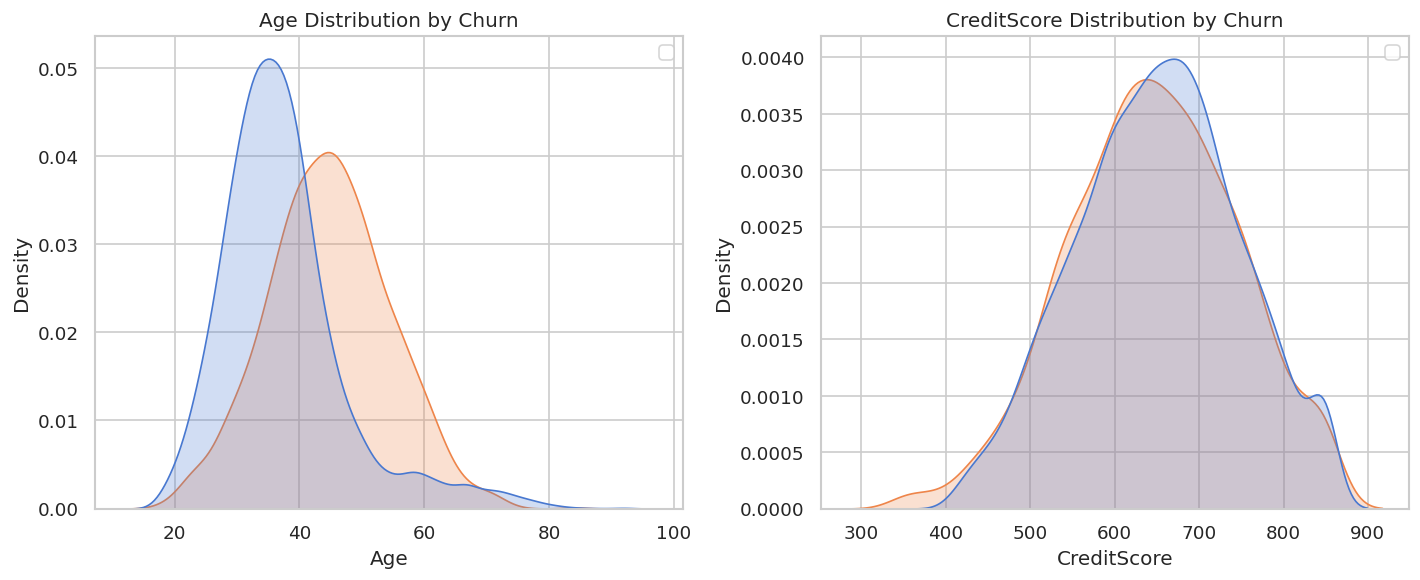

In [8]:
plot_kde_by_churn(train_df, cols=['Age', 'CreditScore'],
    save_path="reports/figures/eda_02_kde_age_creditscore.png")

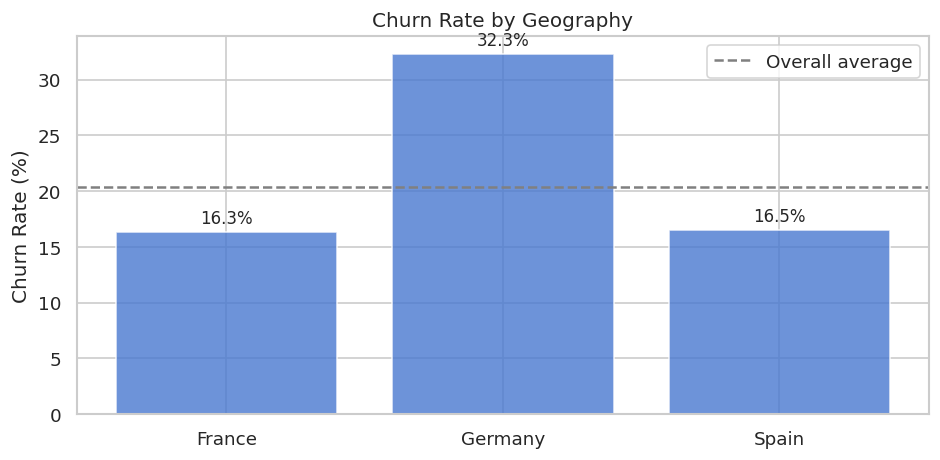

In [9]:
plot_churn_rate_bar(train_df, 'Geography', title='Churn Rate by Geography',
    save_path="reports/figures/eda_03_churn_geography.png")

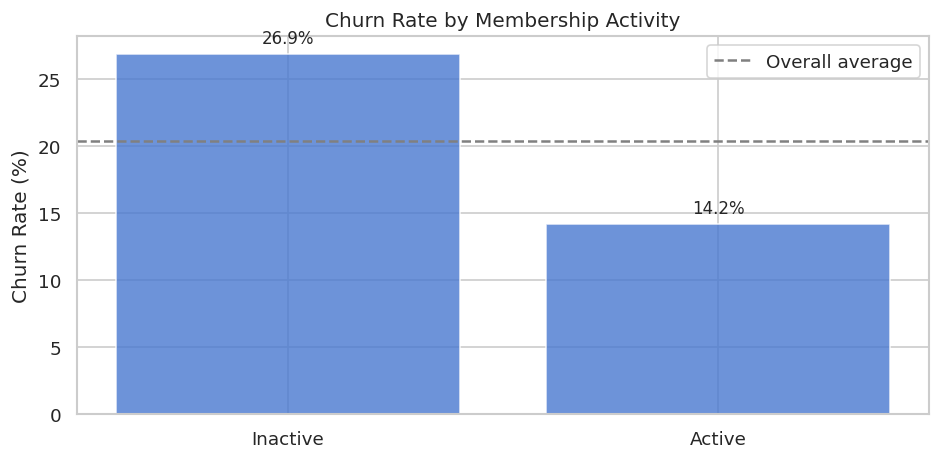

In [10]:
plot_churn_rate_bar(train_df, 'IsActiveMember', title='Churn Rate by Membership Activity',
    x_labels=['Inactive', 'Active'],
    save_path="reports/figures/eda_04_churn_activity.png")

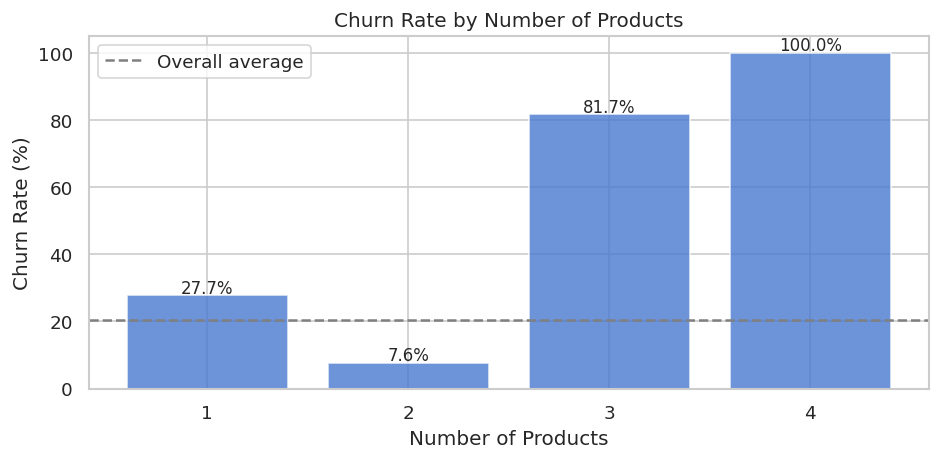

In [11]:
plot_churn_rate_bar(train_df, 'NumOfProducts', title='Churn Rate by Number of Products',
    xlabel='Number of Products',
    save_path="reports/figures/eda_05_churn_products.png")

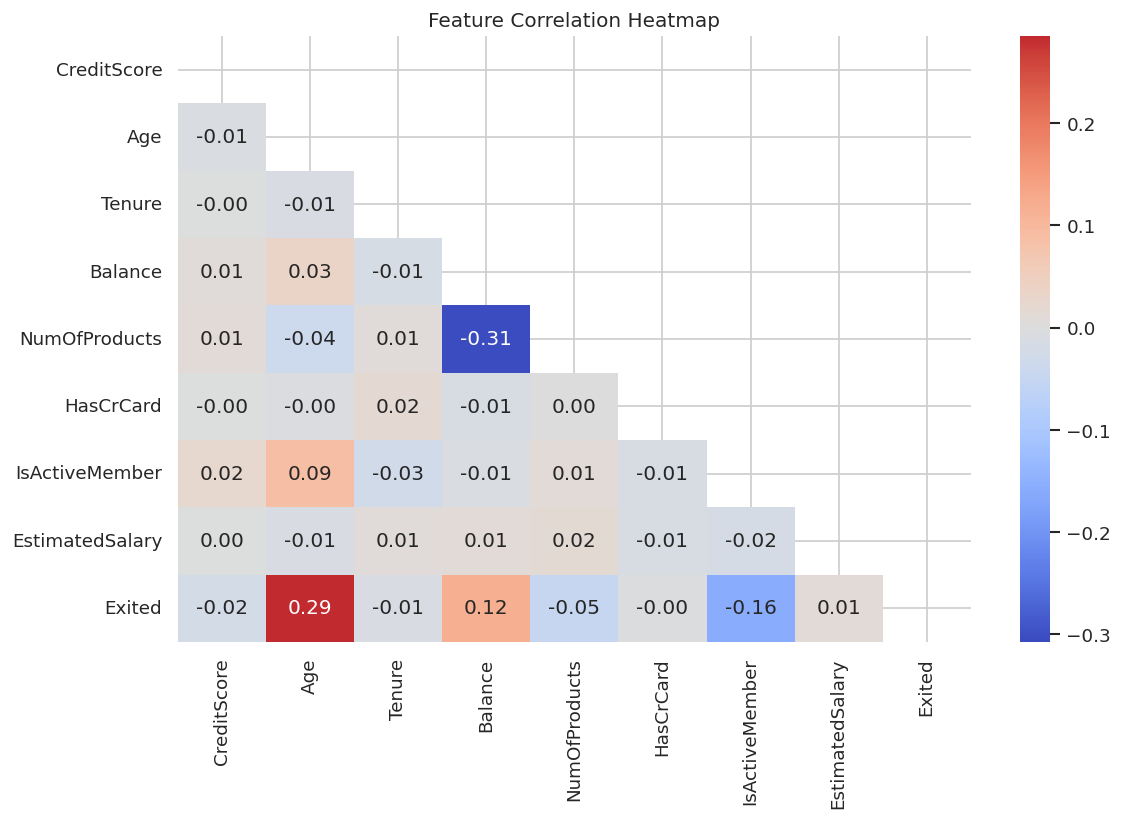

No redundant features found.


In [12]:
plot_correlation_heatmap(train_df,
    save_path="reports/figures/eda_06_correlation.png")

# 5 - MODEL COMPARISON STUDY

In [13]:
NUM_FEATURES         = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
                         "EstimatedSalary", "BalanceSalaryRatio", "ProductsPerYear"]
CAT_FEATURES         = ["Geography", "Gender", "AgeGroup"]
PASSTHROUGH_FEATURES = ["HasCrCard", "IsActiveMember", "IsActive_by_CreditCard"]

In [14]:
N_SPLITS = 5
skf      = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
ratio    = (y_train == 0).sum() / (y_train == 1).sum()

In [15]:
RECALL_FLOOR = 0.60
W_RECALL     = 0.40
W_F1         = 0.35
W_AUC        = 0.25

def score_from_metrics(f1_, recall_, auc_):
    """
    Composite score for tournament selection.
    Applies a hard penalty if recall is below the business floor.
    Used directly on aggregated CV metrics — no raw predictions needed.
    """
    score = W_F1 * f1_ + W_RECALL * recall_ + W_AUC * auc_
    return score


In [16]:
# Each model defined as weighted (class_weight) and plain (for SMOTE / ADASYN)
MODELS = {
    "Logistic Regression": {
        "weighted": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED),
        "plain"   : LogisticRegression(max_iter=1000, random_state=SEED),
    },
    "Random Forest": {
        "weighted": RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=SEED, n_jobs=-1),
        "plain"   : RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    },
    "Extra Trees": {
        "weighted": ExtraTreesClassifier(class_weight='balanced', n_estimators=200, random_state=SEED, n_jobs=-1),
        "plain"   : ExtraTreesClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    },
    "XGBoost": {
        "weighted": XGBClassifier(scale_pos_weight=ratio, eval_metric='logloss', verbosity=0, random_state=SEED),
        "plain"   : XGBClassifier(eval_metric='logloss', verbosity=0, random_state=SEED),
    },
    "LightGBM": {
        "weighted": LGBMClassifier(is_unbalance=True, n_estimators=200, verbosity=-1, random_state=SEED, n_jobs=-1),
        "plain"   : LGBMClassifier(n_estimators=200, verbosity=-1, random_state=SEED, n_jobs=-1),
    },
    "CatBoost": {
        "weighted": CatBoostClassifier(auto_class_weights='Balanced', iterations=200, verbose=0, random_seed=SEED),
        "plain"   : CatBoostClassifier(iterations=200, verbose=0, random_seed=SEED),
    },
}
STRATEGIES = ["class_weight", "SMOTE", "ADASYN"]


In [17]:
tournament_results = []
print("Running full tournament ...\n")

for model_name, variants in MODELS.items():
    for strategy in STRATEGIES:
        model = variants["weighted"] if strategy == "class_weight" else variants["plain"]
        pipe  = build_pipeline(
            classifier           = model,
            num_features         = NUM_FEATURES,
            cat_features         = CAT_FEATURES,
            passthrough_features = PASSTHROUGH_FEATURES,
            use_smote            = (strategy == "SMOTE"),
            use_adasyn           = (strategy == "ADASYN"),
        )
        scores = cross_validate(pipe, X_train, y_train, cv=skf,
                                scoring=['roc_auc', 'f1', 'recall'], n_jobs=-1)
        tournament_results.append({
            'Model'   : model_name,
            'Strategy': strategy,
            'ROC-AUC' : scores['test_roc_auc'].mean(),
            'F1'      : scores['test_f1'].mean(),
            'Recall'  : scores['test_recall'].mean(),
        })
        print(f"  {model_name:<22} | {strategy:<12} | AUC={scores['test_roc_auc'].mean():.4f}  F1={scores['test_f1'].mean():.4f}  Recall={scores['test_recall'].mean():.4f}")

Running full tournament ...

  Logistic Regression    | class_weight | AUC=0.7753  F1=0.4948  Recall=0.7141
  Logistic Regression    | SMOTE        | AUC=0.7740  F1=0.4952  Recall=0.7016
  Logistic Regression    | ADASYN       | AUC=0.7670  F1=0.4827  Recall=0.6989
  Random Forest          | class_weight | AUC=0.8507  F1=0.5519  Recall=0.4305
  Random Forest          | SMOTE        | AUC=0.8490  F1=0.5969  Recall=0.5499
  Random Forest          | ADASYN       | AUC=0.8472  F1=0.5965  Recall=0.5614
  Extra Trees            | class_weight | AUC=0.8391  F1=0.5499  Recall=0.4419
  Extra Trees            | SMOTE        | AUC=0.8379  F1=0.5771  Recall=0.5194
  Extra Trees            | ADASYN       | AUC=0.8360  F1=0.5785  Recall=0.5259
  XGBoost                | class_weight | AUC=0.8359  F1=0.5867  Recall=0.6159
  XGBoost                | SMOTE        | AUC=0.8405  F1=0.5904  Recall=0.5368
  XGBoost                | ADASYN       | AUC=0.8395  F1=0.5834  Recall=0.5270
  LightGBM             

In [18]:
tournament_df          = pd.DataFrame(tournament_results)
tournament_df['Score'] = tournament_df.apply(
    lambda r: score_from_metrics(r['F1'], r['Recall'], r['ROC-AUC']), axis=1
)
tournament_df = tournament_df.sort_values('Score', ascending=False).reset_index(drop=True)

best_row        = tournament_df.iloc[0]
BEST_MODEL_NAME = best_row['Model']
BEST_STRATEGY   = best_row['Strategy']

display(tournament_df)
print(f"\nWinner : {BEST_MODEL_NAME} + {BEST_STRATEGY}")
print(f"  Score={best_row['Score']:.4f}  F1={best_row['F1']:.4f}  AUC={best_row['ROC-AUC']:.4f}  Recall={best_row['Recall']:.4f}")


,Model,Strategy,ROC-AUC,F1,Recall,Score
0,CatBoost,class_weight,0.856730,0.604328,0.702704,0.706779
1,LightGBM,class_weight,0.847965,0.593909,0.636142,0.674316
2,XGBoost,class_weight,0.835858,0.586691,0.615942,0.660683
3,Logistic Regression,class_weight,0.775310,0.494775,0.714142,0.652656
4,Logistic Regression,SMOTE,0.773995,0.495215,0.701584,0.647458
5,CatBoost,SMOTE,0.857883,0.608303,0.546112,0.645821
6,Random Forest,ADASYN,0.847236,0.596548,0.561393,0.645158
7,CatBoost,ADASYN,0.856189,0.610491,0.542294,0.644637
8,Random Forest,SMOTE,0.849038,0.596902,0.549929,0.641147
9,Logistic Regression,ADASYN,0.766953,0.482741,0.698858,0.640241



Winner : CatBoost + class_weight
  Score=0.7068  F1=0.6043  AUC=0.8567  Recall=0.7027


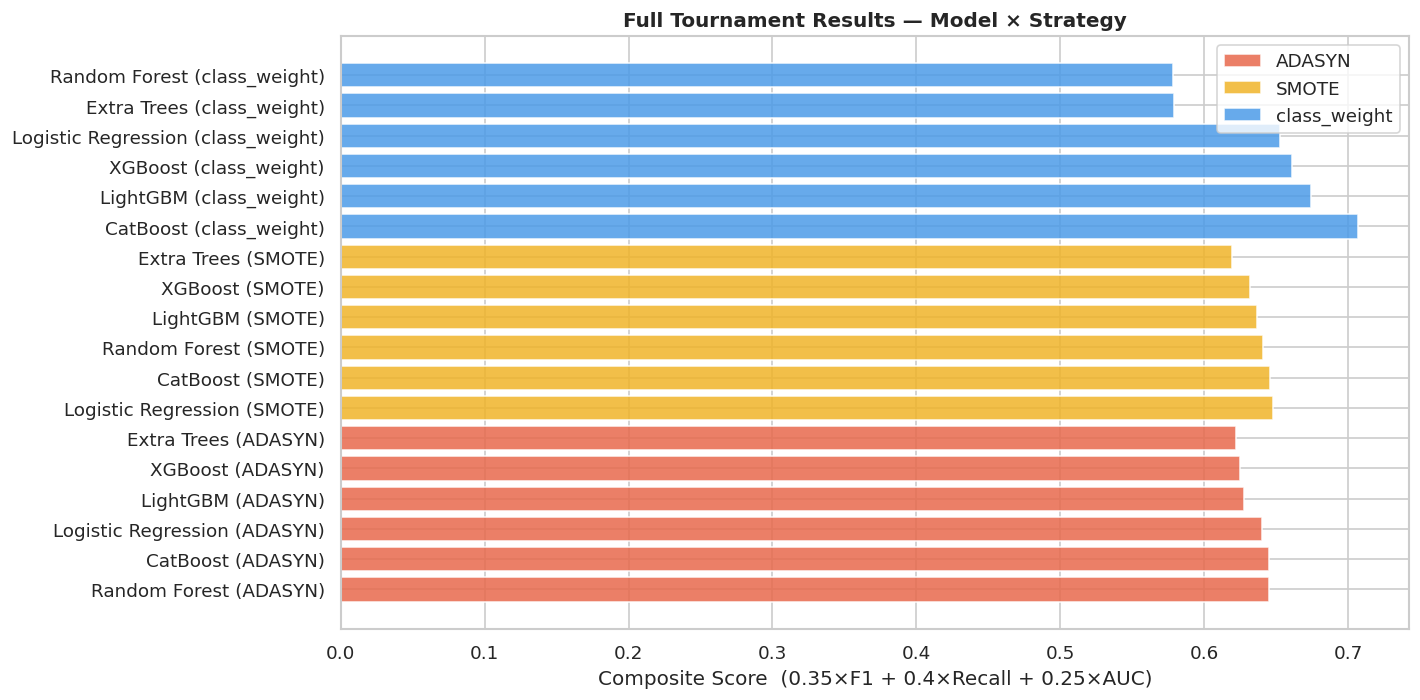

In [19]:
# tournament bar chart
fig, ax = plt.subplots(figsize=(12, 6))
palette = {'class_weight': '#4C9BE8', 'SMOTE': '#F0B429', 'ADASYN': '#E8694C'}
for strategy, grp in tournament_df.groupby('Strategy'):
    ax.barh(
        [f"{r['Model']} ({r['Strategy']})" for _, r in grp.iterrows()],
        grp['Score'], color=palette[strategy], alpha=0.85, label=strategy
    )
ax.set_xlabel(f'Composite Score  ({W_F1}×F1 + {W_RECALL}×Recall + {W_AUC}×AUC)')
ax.set_title('Full Tournament Results — Model × Strategy', fontweight='bold')
ax.legend()
plt.tight_layout()
fig.savefig("reports/figures/model_01_tournament.png", dpi=150, bbox_inches="tight")
plt.show()

# 6 - HYPERPARAMETER TUNING  (Optuna)

In [20]:
def churn_score(y_true, y_pred, y_proba):
    """
    Composite score for Optuna objective.
    Same logic as score_from_metrics but operates on raw arrays.
    Passed as score_fn to make_objective so tuning optimises
    the same business-aware goal as tournament selection.
    """
    f1_     = f1_score(y_true, y_pred)
    recall_ = recall_score(y_true, y_pred)
    auc_    = roc_auc_score(y_true, y_proba)
    return score_from_metrics(f1_, recall_, auc_)

In [21]:
OPTUNA_TRIALS = 150

if BEST_MODEL_NAME == "LightGBM":
    if BEST_STRATEGY == "class_weight":
        model_fn     = lambda **p: LGBMClassifier(**p, verbosity=-1, random_state=SEED,
                                                   n_jobs=-1, is_unbalance=True)
        fixed_params = {"verbosity": -1, "random_state": SEED, "n_jobs": -1, "is_unbalance": True}
    else:
        model_fn     = lambda **p: LGBMClassifier(**p, verbosity=-1, random_state=SEED, n_jobs=-1)
        fixed_params = {"verbosity": -1, "random_state": SEED, "n_jobs": -1}
    param_space = {
        "n_estimators"    : lambda t: t.suggest_int("n_estimators", 100, 1000),
        "learning_rate"   : lambda t: t.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "num_leaves"      : lambda t: t.suggest_int("num_leaves", 20, 200),
        "max_depth"       : lambda t: t.suggest_int("max_depth", 3, 12),
        "subsample"       : lambda t: t.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": lambda t: t.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"       : lambda t: t.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"      : lambda t: t.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
    }

elif BEST_MODEL_NAME in ("Random Forest", "Extra Trees"):
    cls = RandomForestClassifier if BEST_MODEL_NAME == "Random Forest" else ExtraTreesClassifier
    if BEST_STRATEGY == "class_weight":
        def model_fn(**p): return cls(**p, random_state=SEED, n_jobs=-1, class_weight="balanced")
        fixed_params = {"bootstrap": True, "random_state": SEED, "n_jobs": -1,
                        "class_weight": "balanced"}
    else:
        def model_fn(**p): return cls(**p, random_state=SEED, n_jobs=-1)
        fixed_params = {"bootstrap": True, "random_state": SEED, "n_jobs": -1}
    param_space = {
        "n_estimators"     : lambda t: t.suggest_int("n_estimators", 100, 800),
        "max_depth"        : lambda t: t.suggest_int("max_depth", 3, 20),
        "min_samples_split": lambda t: t.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf" : lambda t: t.suggest_int("min_samples_leaf", 1, 10),
        "max_features"     : lambda t: t.suggest_categorical("max_features", ["sqrt", "log2"]),
    }

elif BEST_MODEL_NAME == "XGBoost":
    if BEST_STRATEGY == "class_weight":
        model_fn     = lambda **p: XGBClassifier(**p, eval_metric='logloss', verbosity=0,
                                                  random_state=SEED, scale_pos_weight=ratio)
        fixed_params = {"eval_metric": "logloss", "verbosity": 0, "random_state": SEED,
                        "scale_pos_weight": ratio}
    else:
        model_fn     = lambda **p: XGBClassifier(**p, eval_metric='logloss', verbosity=0,
                                                  random_state=SEED)
        fixed_params = {"eval_metric": "logloss", "verbosity": 0, "random_state": SEED}
    param_space = {
        "n_estimators"    : lambda t: t.suggest_int("n_estimators", 100, 1000),
        "learning_rate"   : lambda t: t.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth"       : lambda t: t.suggest_int("max_depth", 3, 12),
        "subsample"       : lambda t: t.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": lambda t: t.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"       : lambda t: t.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"      : lambda t: t.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
    }

elif BEST_MODEL_NAME == "CatBoost":
    if BEST_STRATEGY == "class_weight":
        model_fn     = lambda **p: CatBoostClassifier(**p, verbose=0, random_seed=SEED,
                                                       auto_class_weights='Balanced')
        fixed_params = {"verbose": 0, "random_seed": SEED, "auto_class_weights": "Balanced"}
    else:
        model_fn     = lambda **p: CatBoostClassifier(**p, verbose=0, random_seed=SEED)
        fixed_params = {"verbose": 0, "random_seed": SEED}
    param_space = {
        "iterations"   : lambda t: t.suggest_int("iterations", 200, 700),
        "learning_rate": lambda t: t.suggest_float("learning_rate", 0.015, 0.10, log=True),
        "depth"        : lambda t: t.suggest_int("depth", 3, 5),
        "l2_leaf_reg"  : lambda t: t.suggest_float("l2_leaf_reg", 0.01, 6.0, log=True),
        "subsample"    : lambda t: t.suggest_float("subsample", 0.50, 0.80)
    }

elif BEST_MODEL_NAME == "Logistic Regression":
    if BEST_STRATEGY == "class_weight":
        model_fn     = lambda **p: LogisticRegression(**p, max_iter=1000, random_state=SEED,
                                                       class_weight='balanced')
        fixed_params = {"max_iter": 1000, "random_state": SEED, "class_weight": "balanced"}
    else:
        model_fn     = lambda **p: LogisticRegression(**p, max_iter=1000, random_state=SEED)
        fixed_params = {"max_iter": 1000, "random_state": SEED}
    param_space = {
        "C"      : lambda t: t.suggest_float("C", 1e-3, 100.0, log=True),
        "solver" : lambda t: t.suggest_categorical("solver", ["lbfgs", "saga"]),
        "penalty": lambda t: t.suggest_categorical("penalty", ["l2", None]),
    }

print(f"Tuning {BEST_MODEL_NAME} + {BEST_STRATEGY}  ({OPTUNA_TRIALS} trials)\n")

Tuning CatBoost + class_weight  (150 trials)



In [22]:
study, best_params_final = run_optuna_study(
    objective_fn       = make_objective(
                             model_fn, param_space,
                             X_train, y_train, skf, BEST_STRATEGY,
                             NUM_FEATURES, CAT_FEATURES, PASSTHROUGH_FEATURES,
                             score_fn = churn_score,
                         ),
    n_trials           = OPTUNA_TRIALS,
    best_params_update = fixed_params,
)

  Trial   0 | Score: 0.6994 ▲ | Params: {'iterations': 387, 'learning_rate': 0.0911, 'depth': 5, 'l2_leaf_reg': 0.4604, 'subsample': 0.5468}
  Trial   1 | Score: 0.7296 ▲ | Params: {'iterations': 278, 'learning_rate': 0.0167, 'depth': 5, 'l2_leaf_reg': 0.4677, 'subsample': 0.7124}
  Trial   4 | Score: 0.7313 ▲ | Params: {'iterations': 506, 'learning_rate': 0.0195, 'depth': 3, 'l2_leaf_reg': 0.1042, 'subsample': 0.6368}
  Trial  37 | Score: 0.7322 ▲ | Params: {'iterations': 484, 'learning_rate': 0.0284, 'depth': 3, 'l2_leaf_reg': 1.1143, 'subsample': 0.5331}


In [23]:
print(f"\nBest composite score : {study.best_value:.4f}")
print(f"Params               : {best_params_final}")


Best composite score : 0.7322
Params               : {'iterations': 484, 'learning_rate': 0.028447478937650972, 'depth': 3, 'l2_leaf_reg': 1.1143102135538125, 'subsample': 0.5331028942366306, 'verbose': 0, 'random_seed': 21, 'auto_class_weights': 'Balanced'}


# 7 - FINAL PIPELINE

In [24]:
final_clf      = model_fn(**{k: v for k, v in best_params_final.items() if k not in fixed_params})
final_pipeline = build_pipeline(
    classifier           = final_clf,
    num_features         = NUM_FEATURES,
    cat_features         = CAT_FEATURES,
    passthrough_features = PASSTHROUGH_FEATURES,
    use_smote            = (BEST_STRATEGY == "SMOTE"),
    use_adasyn           = (BEST_STRATEGY == "ADASYN"),
)
final_pipeline.fit(X_train, y_train)

print(f"Pipeline trained: FeatureEngineer -> Preprocessor -> {BEST_STRATEGY} -> {BEST_MODEL_NAME}")

Pipeline trained: FeatureEngineer -> Preprocessor -> class_weight -> CatBoost


# 8 - THRESHOLD SELECTION

  Recall floor  : 0.6
  Best threshold: 0.6289
  Precision     : 0.629
  Recall        : 0.638
  F1            : 0.633


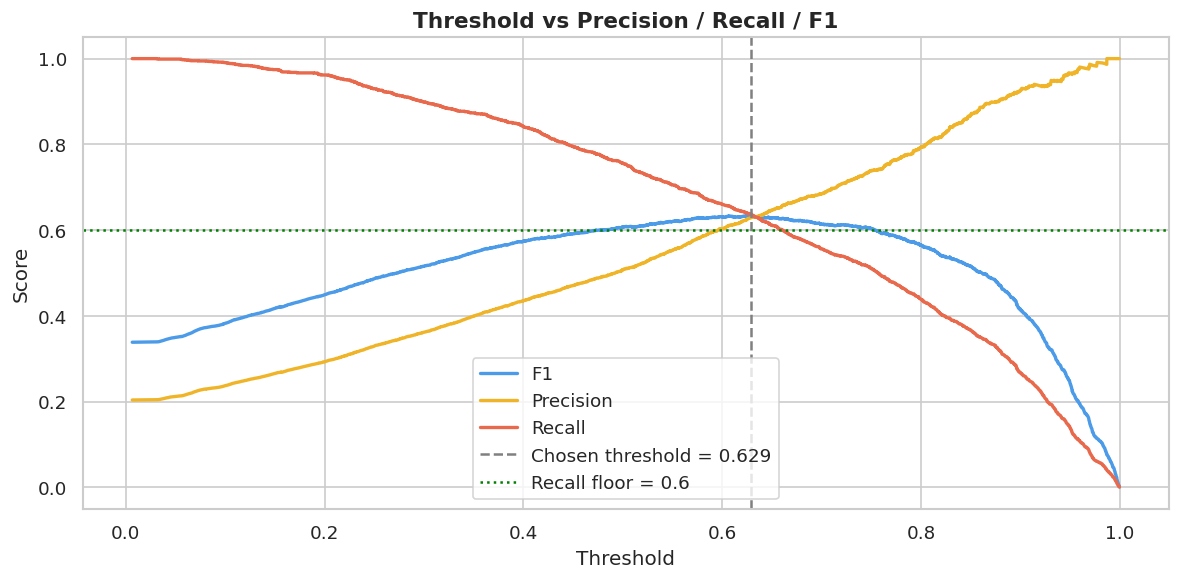

In [25]:
best_threshold, precisions, recalls, thresholds, f1_arr = find_optimal_threshold(
    final_pipeline, X_train, y_train, skf, recall_floor=RECALL_FLOOR
)

plot_threshold_curve(thresholds, precisions, recalls, f1_arr, best_threshold, RECALL_FLOOR,
    save_path="reports/figures/eval_01_threshold_curve.png")

# 9 - TEST SET EVALUATION

In [26]:
y_probas_test = final_pipeline.predict_proba(X_test)[:, 1]
y_pred_test   = (y_probas_test >= best_threshold).astype(int)

auc       = roc_auc_score(y_test, y_probas_test)
f1        = f1_score(y_test, y_pred_test)
recall    = recall_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)

results_summary = pd.DataFrame({
    'Metric'   : ['ROC-AUC', 'F1', 'Recall', 'Precision'],
    'Score'    : [auc, f1, recall, precision],
    'Target'   : [0.85, 0.55, 0.60, 0.50],
}).assign(Status=lambda d: d.apply(
    lambda r: 'PASS' if r['Score'] >= r['Target'] else 'FAIL', axis=1
)).set_index('Metric')

print(f"\n{BEST_MODEL_NAME}  |  threshold = {best_threshold:.4f}\n")
display(results_summary.style.format({'Score': '{:.4f}', 'Target': '{:.2f}'}))


CatBoost  |  threshold = 0.6289



,Score,Target,Status
Metric,,,
ROC-AUC,0.8794,0.85,PASS
F1,0.6537,0.55,PASS
Recall,0.6569,0.60,PASS
Precision,0.6505,0.50,PASS


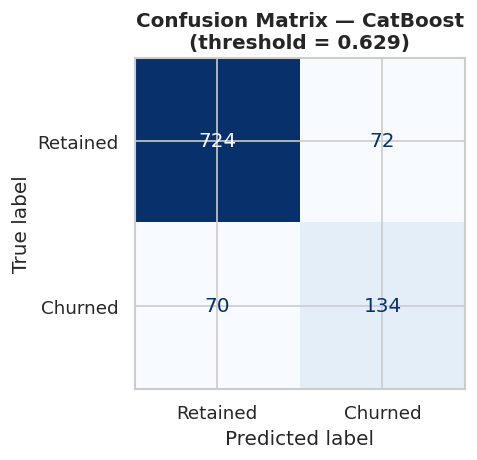

In [27]:
plot_confusion_matrix(y_test, y_pred_test, best_threshold, BEST_MODEL_NAME,
    save_path="reports/figures/eval_02_confusion_matrix.png")

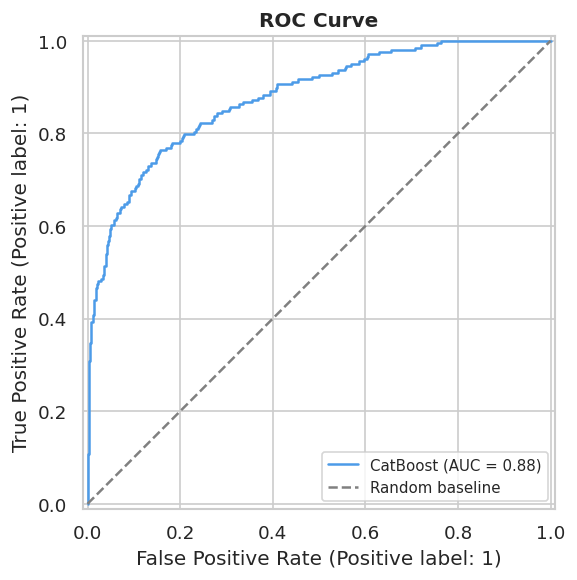

In [28]:
plot_roc_curve(y_test, y_probas_test, auc, BEST_MODEL_NAME,
    save_path="reports/figures/eval_03_roc_curve.png")

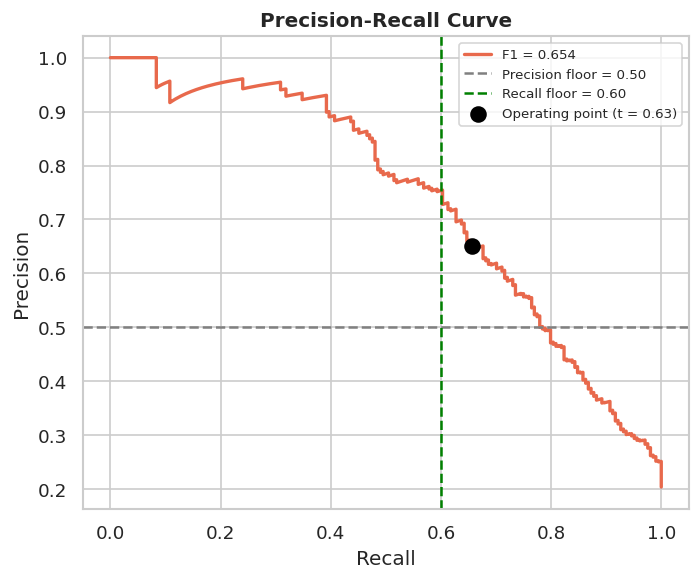

In [29]:
plot_pr_curve(y_test, y_probas_test, best_threshold, recall, precision, f1,
    save_path="reports/figures/eval_04_pr_curve.png")

# 10 - CALIBRATION

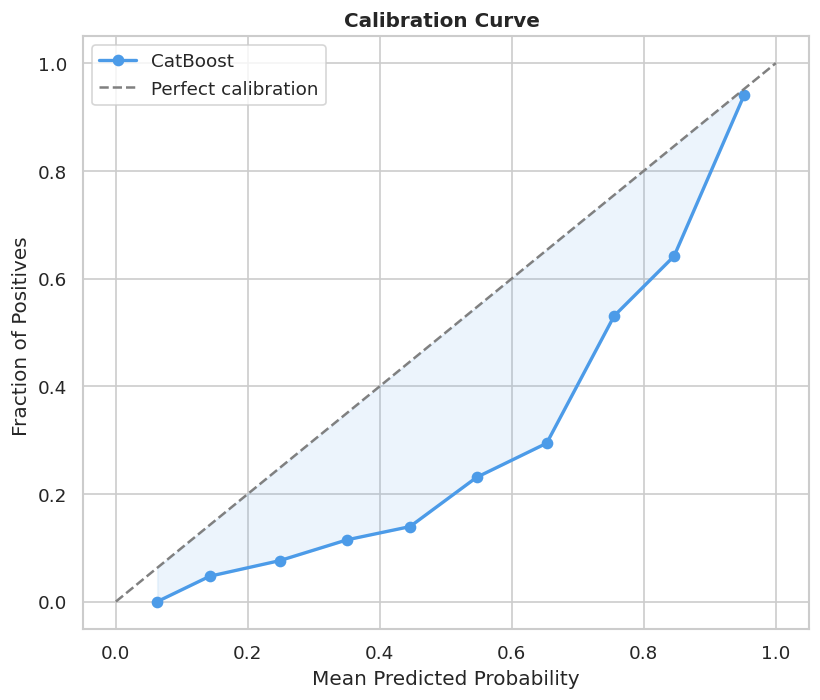

In [30]:
plot_calibration_curve(y_test, y_probas_test, BEST_MODEL_NAME,
    save_path="reports/figures/eval_05_calibration_before.png")

In [31]:
calibrated_pipeline = CalibratedClassifierCV(
    final_pipeline,
    method = 'isotonic',
    cv     = 'prefit',
)
calibrated_pipeline.fit(X_train, y_train)
print("Isotonic calibration applied.")


Isotonic calibration applied.


In [32]:
# get calibrated probabilities
y_probas_cal = calibrated_pipeline.predict_proba(X_test)[:, 1]

# find threshold on calibrated probabilities via PR curve on test set
prec_cal, rec_cal, thresh_cal = precision_recall_curve(y_test, y_probas_cal)
f1_cal    = 2 * (prec_cal * rec_cal) / (prec_cal + rec_cal + 1e-8)
valid_idx = np.where(rec_cal[:-1] >= RECALL_FLOOR)[0]

if len(valid_idx) == 0:
    print(f"  No threshold achieves Recall ≥ {RECALL_FLOOR}. Using global F1 max.")
    best_idx = np.argmax(f1_cal[:-1])
else:
    best_idx = valid_idx[np.argmax(f1_cal[valid_idx])]

best_threshold_cal = thresh_cal[best_idx]

print(f"  Uncalibrated threshold : {best_threshold:.4f}")
print(f"  Calibrated threshold   : {best_threshold_cal:.4f}")
print(f"  Precision              : {prec_cal[best_idx]:.3f}")
print(f"  Recall                 : {rec_cal[best_idx]:.3f}")
print(f"  F1                     : {f1_cal[best_idx]:.3f}")

y_pred_cal = (y_probas_cal >= best_threshold_cal).astype(int)


  Uncalibrated threshold : 0.6289
  Calibrated threshold   : 0.4416
  Precision              : 0.720
  Recall                 : 0.618
  F1                     : 0.665


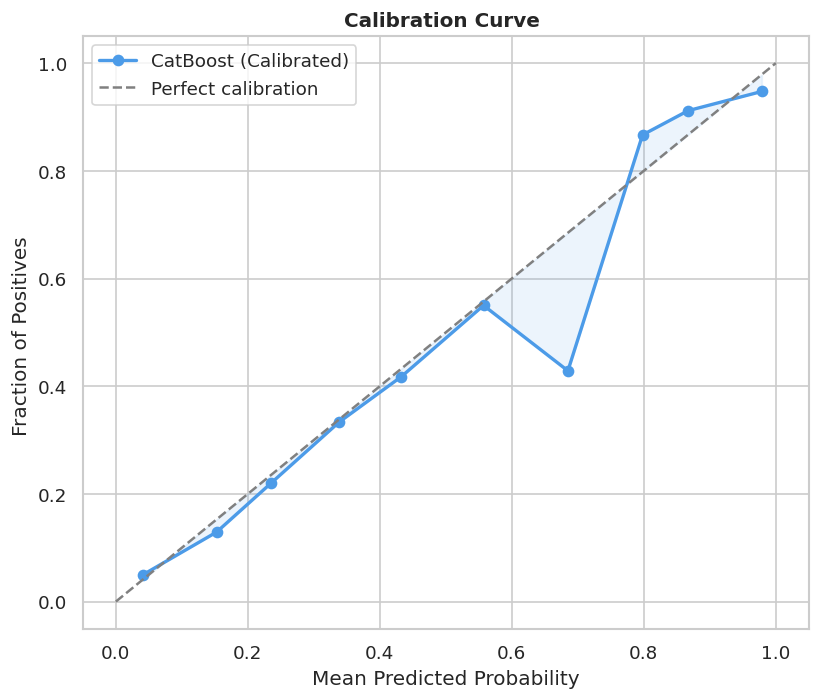

In [33]:
plot_calibration_curve(y_test, y_probas_cal, f"{BEST_MODEL_NAME} (Calibrated)",
    save_path="reports/figures/eval_06_calibration_after.png")

In [34]:
#Re-evaluation on calibrated model
auc_cal       = roc_auc_score(y_test, y_probas_cal)
f1_cal_score  = f1_score(y_test, y_pred_cal)
recall_cal    = recall_score(y_test, y_pred_cal)
precision_cal = precision_score(y_test, y_pred_cal)

results_summary_cal = pd.DataFrame({
    'Metric' : ['ROC-AUC', 'F1', 'Recall', 'Precision'],
    'Score'  : [auc_cal, f1_cal_score, recall_cal, precision_cal],
    'Target' : [0.85, 0.55, 0.60, 0.50],
}).assign(Status=lambda d: d.apply(
    lambda r: 'PASS' if r['Score'] >= r['Target'] else 'FAIL', axis=1
)).set_index('Metric')

print(f"\n{BEST_MODEL_NAME} (Calibrated)  |  threshold = {best_threshold_cal:.4f}\n")
display(results_summary_cal.style.format({'Score': '{:.4f}', 'Target': '{:.2f}'}))


CatBoost (Calibrated)  |  threshold = 0.4416



,Score,Target,Status
Metric,,,
ROC-AUC,0.8774,0.85,PASS
F1,0.6649,0.55,PASS
Recall,0.6176,0.60,PASS
Precision,0.7200,0.50,PASS


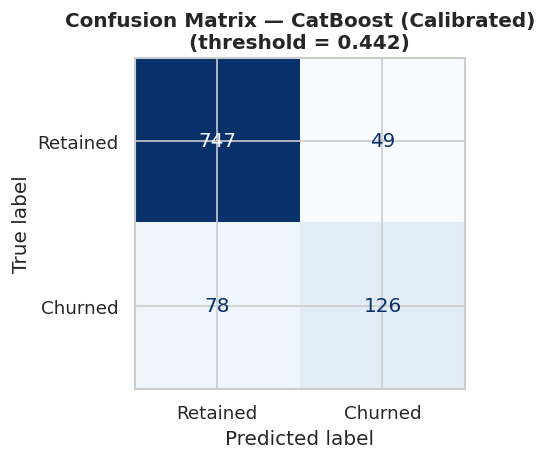

In [35]:
plot_confusion_matrix(y_test, y_pred_cal, best_threshold_cal,
    f"{BEST_MODEL_NAME} (Calibrated)",
    save_path="reports/figures/eval_07_confusion_matrix_calibrated.png")

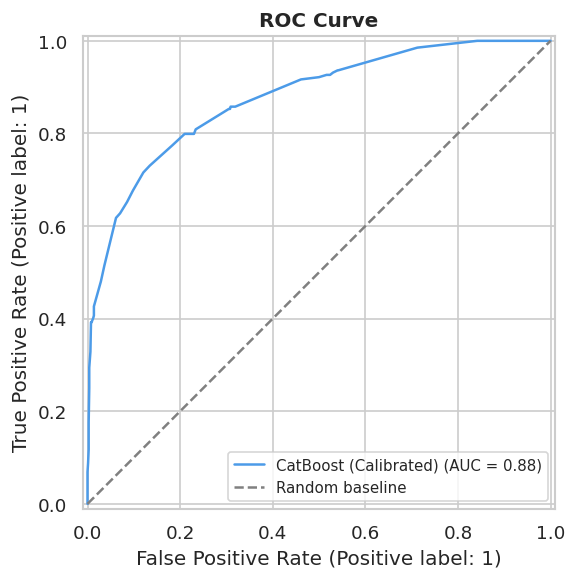

In [36]:
plot_roc_curve(y_test, y_probas_cal, auc_cal,
    f"{BEST_MODEL_NAME} (Calibrated)",
    save_path="reports/figures/eval_08_roc_curve_calibrated.png")

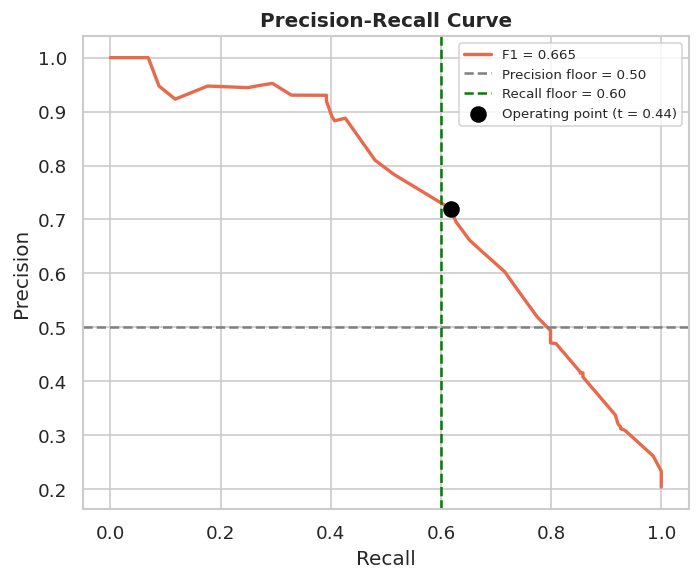

In [37]:
plot_pr_curve(y_test, y_probas_cal, best_threshold_cal,
    recall_cal, precision_cal, f1_cal_score,
    save_path="reports/figures/eval_09_pr_curve_calibrated.png")

# 11 - Error Analysis

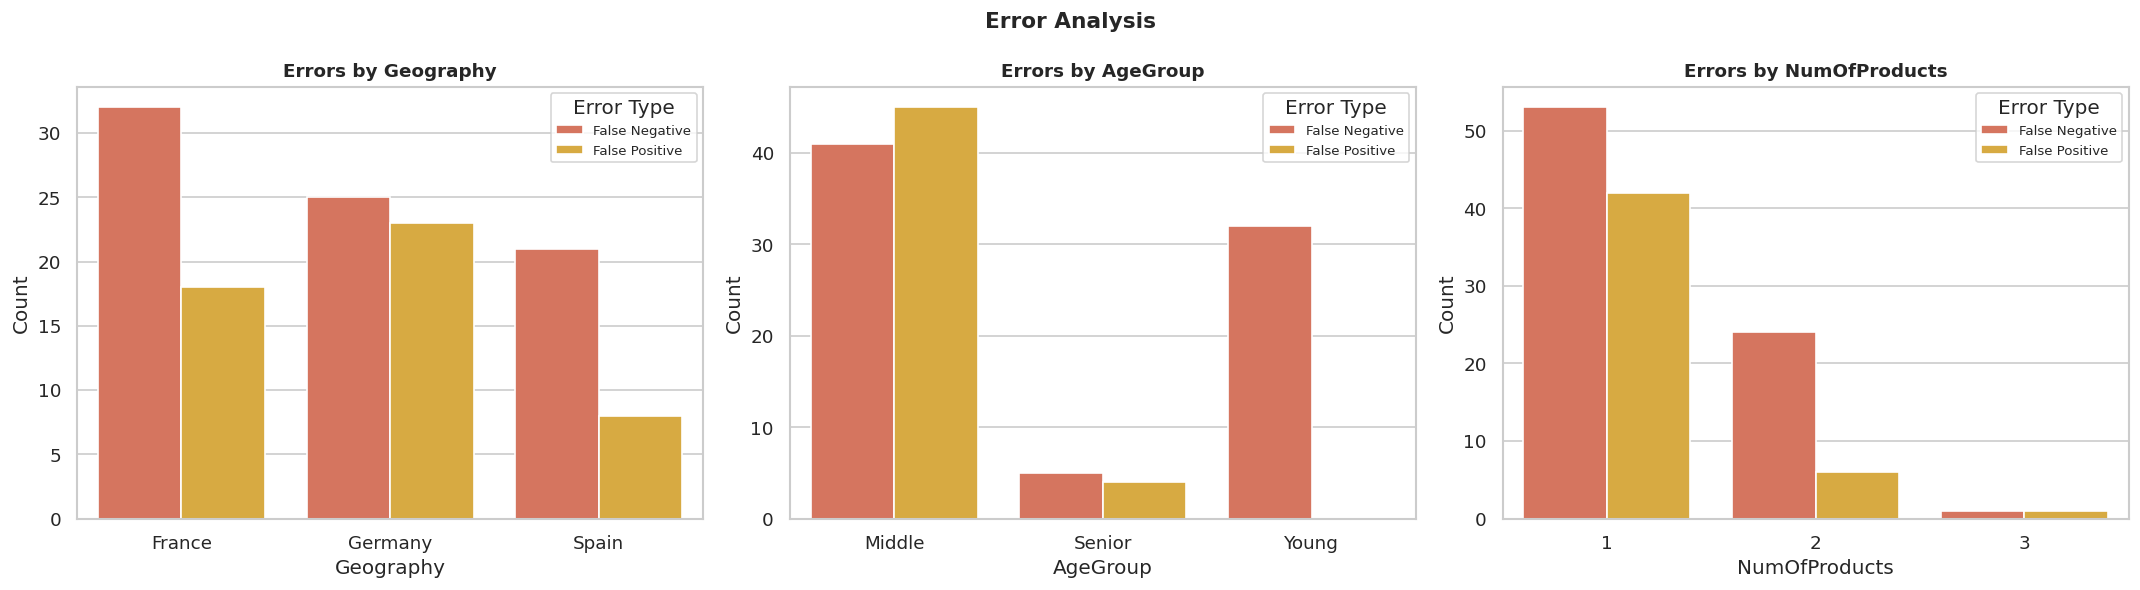


Total errors       : 127 / 1,000 (12.7%)
False Negatives    : 78  (missed churners) 
False Positives    : 49  (wrong alarms) 


In [38]:
error_df = plot_error_analysis(X_test, y_test, y_pred_cal, y_probas_cal,
    save_path="reports/figures/eval_10_error_analysis.png")

# 12 - SHAP INTERPRETABILITY

In [39]:
trained_classifier = final_pipeline.named_steps['classifier']
X_test_df, all_feature_names = get_transformed_test_data(
    final_pipeline, X_test, NUM_FEATURES, CAT_FEATURES, PASSTHROUGH_FEATURES
)

MODEL_TYPE  = "linear" if BEST_MODEL_NAME == "Logistic Regression" else "tree"
explainer   = build_shap_explainer(trained_classifier, X_test_df, MODEL_TYPE)
shap_values = explainer.shap_values(X_test_df)
sv          = get_shap_values_class1(shap_values)

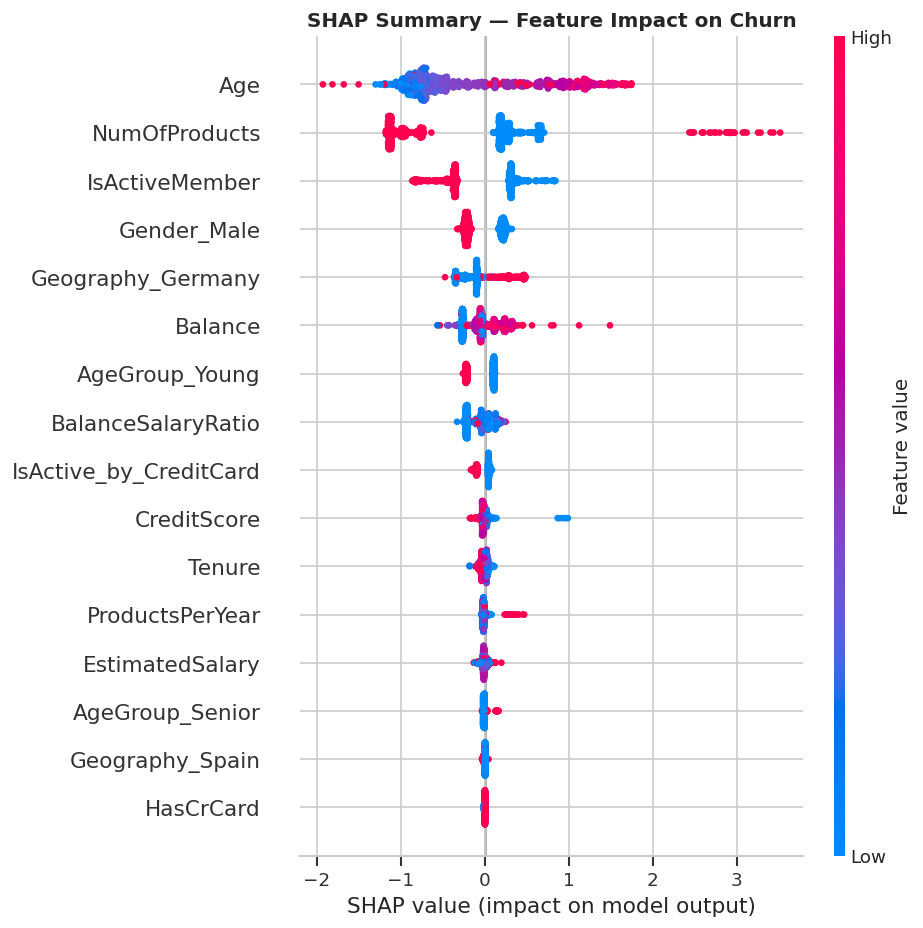

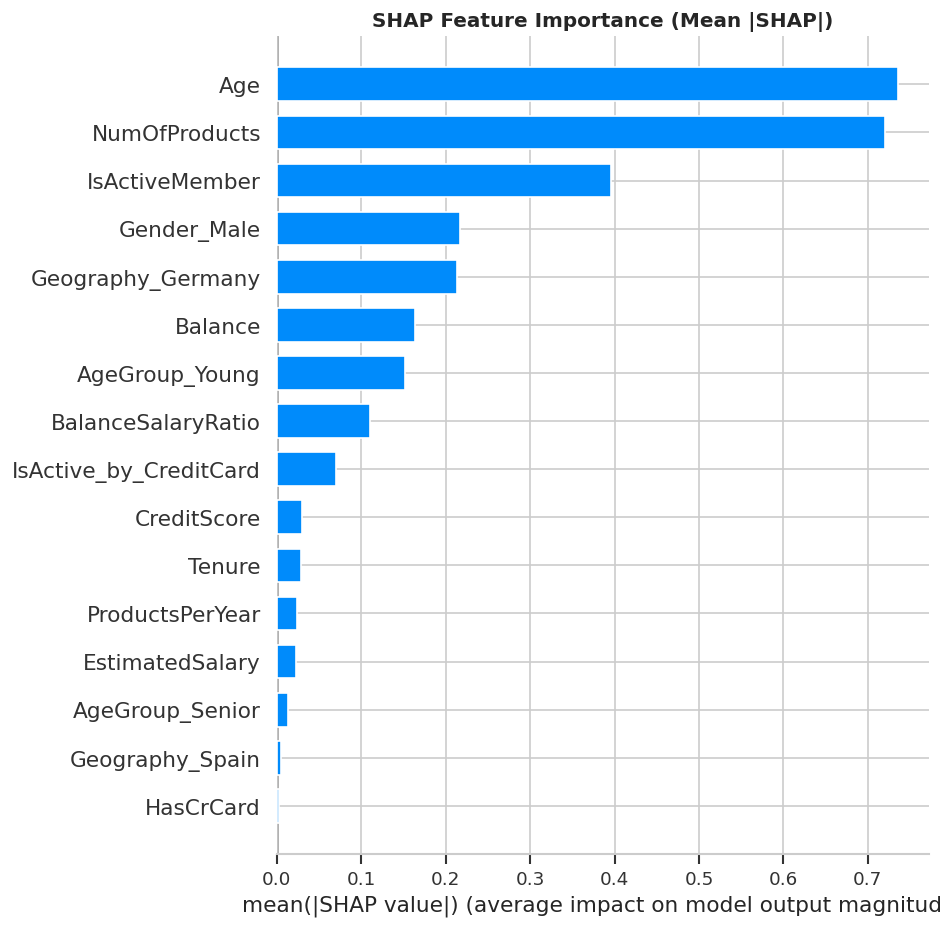


Top 10 features by mean |SHAP|:
Age                       0.735405
NumOfProducts             0.720863
IsActiveMember            0.396377
Gender_Male               0.216793
Geography_Germany         0.213753
Balance                   0.163825
AgeGroup_Young            0.151972
BalanceSalaryRatio        0.110079
IsActive_by_CreditCard    0.070300
CreditScore               0.030097


In [40]:
# global feature importance
plot_shap_summary(sv, X_test_df, save_dir="reports/figures")

In [41]:
# individual prediction explanation (first true-positive churner)
churned_mask = (y_test.values == 1) & (y_pred_cal == 1)
tp_indices   = np.where(churned_mask)[0]

  Customer index        : 4
  Predicted probability : 81.60%
  Actual label          : CHURN


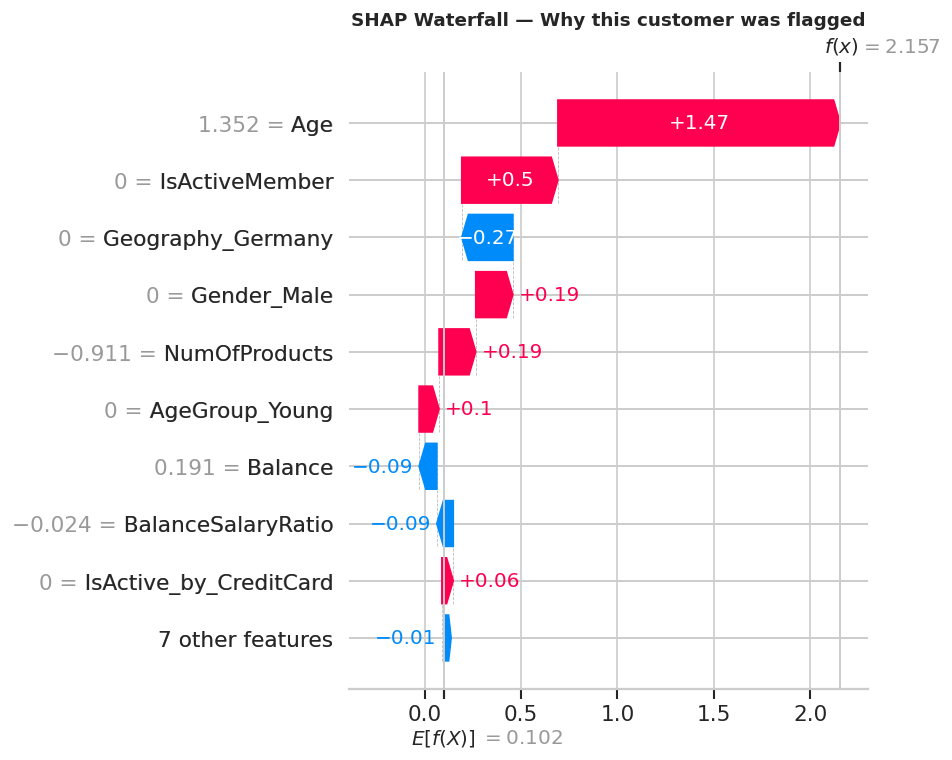

In [42]:
if len(tp_indices) == 0:
    print("No true-positive churners found. Lower the threshold or inspect FP cases.")
else:
    idx      = tp_indices[0]
    customer = pd.Series(X_test_df.iloc[idx])
    plot_shap_waterfall(explainer=explainer, customer=customer,
      all_feature_names=all_feature_names,
      y_probas_test=y_probas_cal, y_test=y_test, idx=idx,
      save_path="reports/figures/shap_03_waterfall.png")

# 13 - SAVING

In [43]:
os.makedirs("reports", exist_ok=True)

tournament_df.to_csv("reports/tournament_results.csv", index=False)

with open("reports/best_params.json", "w") as f:
    json.dump(best_params_final, f, indent=2, default=str)

results_summary_cal.reset_index().to_csv("reports/test_metrics.csv", index=False)

if error_df is not None:
    error_df.to_csv("reports/error_analysis.csv", index=False)

In [44]:
save_pipeline_and_results(
    final_pipeline = calibrated_pipeline,
    model_name     = BEST_MODEL_NAME,
    best_threshold = best_threshold_cal,
    y_test         = y_test,
    y_pred_test    = y_pred_cal,
    y_probas_test  = y_probas_cal,
)

Pipeline saved  -> models/CatBoost_final_pipeline.joblib
Threshold saved -> models/CatBoost_threshold.joblib  (value: 0.4416)
Predictions saved -> models/test_predictions.csv
   Accuracy : 87.30%
   Rows     : 1,000


# 14 - PUSH TO GITHUB

In [46]:
import requests, base64, glob
from google.colab import userdata

GITHUB_TOKEN  = userdata.get("GITHUB_TOKEN")
GITHUB_REPO   = "narendrapatel6321-dotcom/bank_churn_prediction"
GITHUB_BRANCH = "main"

FILES_TO_PUSH = [
    # Models
    f"models/{BEST_MODEL_NAME}_final_pipeline.joblib",
    f"models/{BEST_MODEL_NAME}_threshold.joblib",
    "models/test_predictions.csv",
    # Reports
    "reports/tournament_results.csv",
    "reports/best_params.json",
    "reports/test_metrics.csv",
    "reports/error_analysis.csv",
] + glob.glob("reports/figures/*.png")

def push_file_to_github(local_path, token, repo, branch):
    repo_path = local_path  # mirrors local structure in the repo
    url       = f"https://api.github.com/repos/{repo}/contents/{repo_path}"
    headers   = {
        "Authorization": f"token {token}",
        "Accept"       : "application/vnd.github.v3+json",
    }
    with open(local_path, "rb") as f:
        content_b64 = base64.b64encode(f.read()).decode()

    # Fetch existing SHA — required to update a file that already exists
    existing = requests.get(url, headers=headers, params={"ref": branch})
    sha      = existing.json().get("sha") if existing.status_code == 200 else None

    payload = {
        "message": f"chore: update {repo_path} via notebook",
        "content": content_b64,
        "branch" : branch,
    }
    if sha:
        payload["sha"] = sha

    response = requests.put(url, headers=headers, json=payload)
    if response.status_code in (200, 201):
        print(f"  [OK]   {repo_path}")
    else:
        print(f"  [FAIL] {repo_path} — {response.json().get('message')}")

print(f"Pushing {len(FILES_TO_PUSH)} files to GitHub...\n")
for local_path in FILES_TO_PUSH:
    if os.path.exists(local_path):
        push_file_to_github(local_path, GITHUB_TOKEN, GITHUB_REPO, GITHUB_BRANCH)
    else:
        print(f" [SKIP] {local_path} — file not found")

print("\nDone.")

Pushing 27 files to GitHub...

  [OK]   models/CatBoost_final_pipeline.joblib
  [OK]   models/CatBoost_threshold.joblib
  [OK]   models/test_predictions.csv
  [OK]   reports/tournament_results.csv
  [OK]   reports/best_params.json
  [OK]   reports/test_metrics.csv
  [OK]   reports/error_analysis.csv
  [OK]   reports/figures/eda_05_churn_products.png
  [OK]   reports/figures/eval_07_confusion_matrix_calibrated.png
  [OK]   reports/figures/eda_06_correlation.png
  [OK]   reports/figures/eval_09_pr_curve_calibrated.png
  [OK]   reports/figures/eval_04_pr_curve.png
  [OK]   reports/figures/eda_03_churn_geography.png
  [OK]   reports/figures/eval_06_calibration_after.png
  [OK]   reports/figures/shap_03_waterfall.png
  [OK]   reports/figures/eda_02_kde_age_creditscore.png
  [OK]   reports/figures/eda_01_class_imbalance.png
  [OK]   reports/figures/eval_05_calibration_before.png
  [OK]   reports/figures/model_01_tournament.png
  [OK]   reports/figures/eval_08_roc_curve_calibrated.png
  [OK] 